In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

In [2]:
# Calculating the number of legal terms (without considering graph equivalence) a graph is split into by collapsing legal combination of nodes

def a_total(n):
    return np.sum([a(n, k) for k in range(1, n+1)])

def a(n, k):
    if(n==k):
        return 1
    if(k==1): 
        # if n is not 1 (this case would be covered by the first base case), there is no way to collapse all field points into one field point without collapsing "illegal" combinations of neighbours 
        # - which are illegal because they give a hopping of 0
        return 0
    return ((k-1)*a(n-1, k) + a(n-1, k-1))

for i in range(1, 6):
    print(f"a({i}) is {a_total(i)}")

print("Contributions to a(4):")
for i in range(2, 5):
    print(f"a(4,{i}) is {a(4, i)}")

print("Contributions to a(5):")
for i in range(2, 6):
    print(f"a(5,{i}) is {a(5, i)}")


a(1) is 1
a(2) is 1
a(3) is 2
a(4) is 5
a(5) is 15
Contributions to a(4):
a(4,2) is 1
a(4,3) is 3
a(4,4) is 1
Contributions to a(5):
a(5,2) is 1
a(5,3) is 7
a(5,4) is 6
a(5,5) is 1


In [3]:
# Solving cubic equation 24 in Lecture 5

def G_average(Delta, x, omega):
    z = omega + 1j * eta
    Vt = 1.0

    coeffs = [
        Vt**4,
        -2*z*Vt**2,
        z**2 - Delta**2 + Vt**2,
        -z + Delta - 2*Delta*x
    ]

    roots = np.roots(coeffs)
    correct_root = roots[0]
    return correct_root

def G_average_fermi_level(Delta, x):
    return G_average(Delta, x, 0.0)


import numpy as np

# Beispielwerte


In [4]:
import numpy as np

FERMI_LEVEL = 0

# TODO machen die nächsten zwei Methoden Sinn?
def fixed_point_update(G, z, Delta, Vt, x):
    return (
        x / (z - Delta - Vt**2 * G)
        + (1 - x) / (z + Delta - Vt**2 * G)
    )

def solve_G_for_omega(z, Delta, Vt, x, G0, tol=1e-10, max_iter=10000, mix=0.5):
    G = G0

    for _ in range(max_iter):
        G_fp = fixed_point_update(G, z, Delta, Vt, x)

        # mixing makes the iteration more stable
        G_new = (1 - mix) * G + mix * G_fp

        if abs(G_new - G) < tol:
            return G_new

        G = G_new

    raise RuntimeError("Self-consistency did not converge")


def G_average_fermi_level(Delta, x):
    omega_max = 10.0 # TODO macht das Sinn?
    eta = 1e-3
    number_of_omegas = 1000
    omegas = np.linspace(omega_max, FERMI_LEVEL, number_of_omegas)
    Vt = 1.0

    results = []

    # initial value from asymptotics
    z0 = omegas[0] + 1j * eta
    G_previous = 1 / z0

    for omega in omegas:
        z = omega + 1j * eta
        G_current = solve_G_for_omega(z, Delta, Vt, x, G_previous)

        results.append(G_current)
        G_previous = G_current
    
    return results[-1]

def DoS_fermi_level(Delta, x):
    return G_average_fermi_level(Delta, x).imag

# oder imaginary part des roots soll kleiner 0 sein?! TODO wie roots auswählen

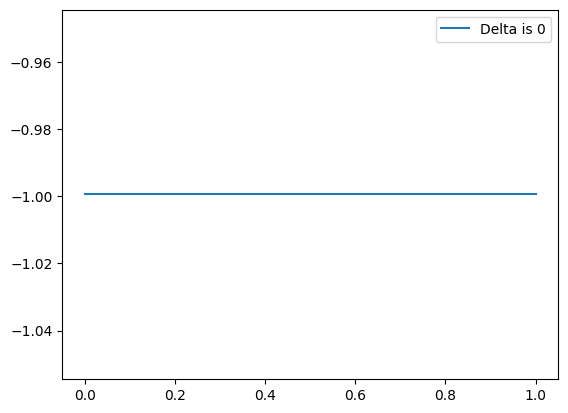

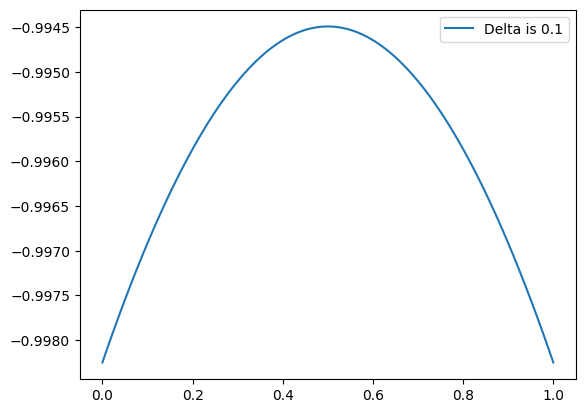

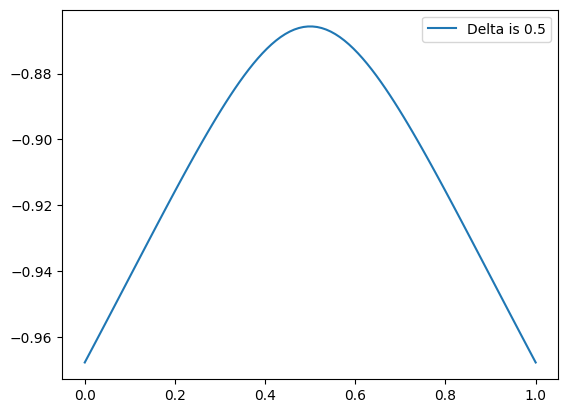

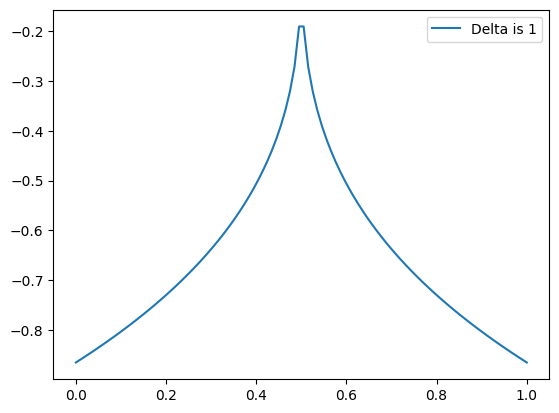

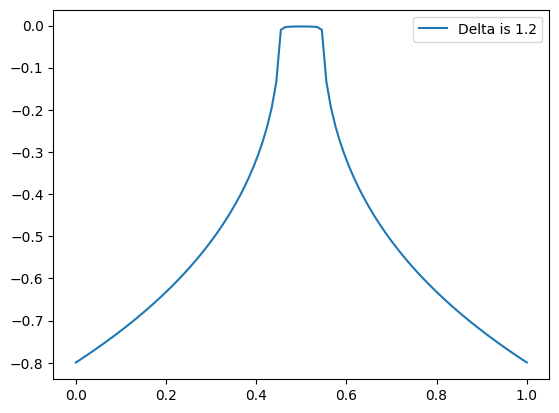

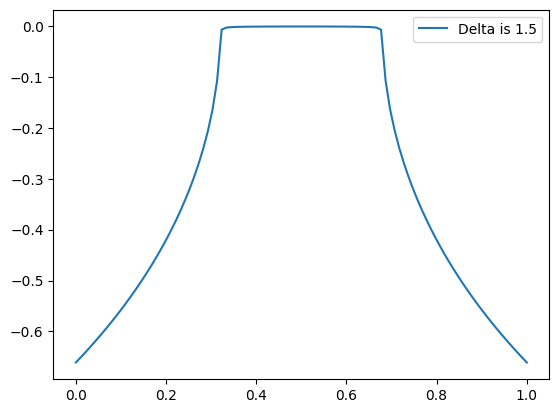

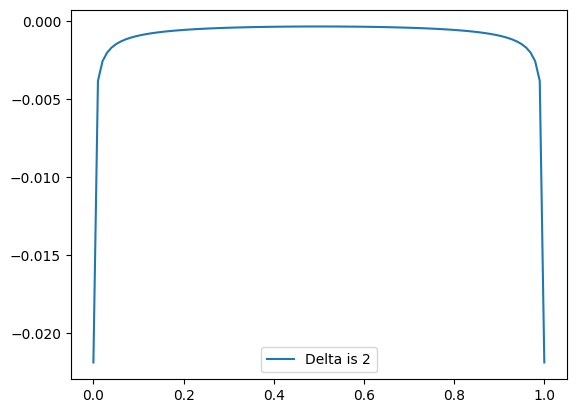

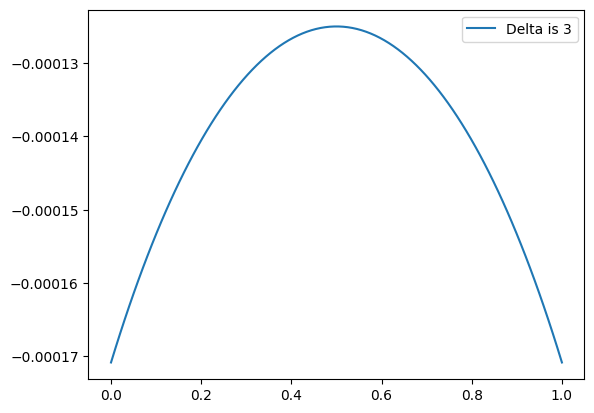

In [5]:
Deltas = [0, 0.1, 0.5, 1, 1.2, 1.5, 2, 3] # mit Energieeinheit abgleichen! TODO
# Delta << 1     weak disorder / small on-site contrast
# Delta ~ 1      moderate disorder
# Delta > 1–2    strong disorder, possible band splitting / gap opening

# TODO diskutieren: Ob ein Gap bei ω=0 entsteht, hängt aber nicht nur von Δ, sondern auch von K, V und x ab. Wenn dein ungestörtes Band etwa
# breit ist, dann muss Δ groß genug sein, um die zwei Bestandteile spektral deutlich zu trennen. Daher sind On-site-Energien der Größenordnung 0 bis ein paar V typische sinnvolle Werte.
xs = np.linspace(0.0, 1.0, 100)

for Delta in Deltas:
    DoS = []
    for x in xs:
        DoS.append(DoS_fermi_level(Delta, x)) # TODO ausgeben lassen wenn DoS actually 0 ist
    plt.plot(xs, DoS, label=f"Delta is {Delta}")
    plt.legend()
    plt.show()



Task 8e)

0.5 0.021984103509927966
1 0.25543468985133894
2 0.653540891229913
4 0.8882942445182664
8 0.9696836473871646
16 0.9922478317589786


/tmp/ipykernel_341758/646955972.py:7: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  val, err = quad(integrand, 0, 1)


In [60]:
import matplotlib.pyplot as plt

import warnings
from scipy.integrate import IntegrationWarning

warnings.simplefilter("ignore", IntegrationWarning)

U_values = np.geomspace(0.1, 7, 100)
mu_values = np.array([solve_mu(U) for U in U_values])


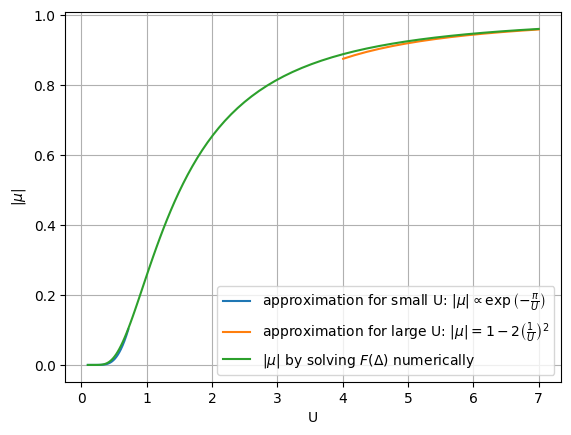

In [62]:
small_mask = U_values <= 0.75
approx_small_U = 8 * np.exp(-np.pi / U_values[small_mask])

large_mask = U_values >= 4
approx_large_U = 1 - 2* (1/ U_values[large_mask])**2

label_exp = r"$|\mu| \propto \exp\left(-\frac{\pi}{U}\right)$"
label_large_U = r"$|\mu| = 1 - 2\left(\frac{1}{U}\right)^2$"
label_mu = r"$|\mu|$ by solving $F(\Delta)$ numerically"

plt.plot(U_values[small_mask], approx_small_U, label=f"approximation for small U: {label_exp}")
plt.plot(U_values[large_mask], approx_large_U, label=f"approximation for large U: {label_large_U}")

plt.plot(U_values, mu_values, label = label_mu)
plt.legend()
plt.xlabel("U")
plt.ylabel(r"$|\mu|$")
plt.grid(True)
plt.savefig("solving_for_mu")
plt.show()

In [ ]:
import numpy as np
from scipy.integrate import quad

def F(Delta):
    integrand = lambda y: np.sqrt(1-y**2) / np.sqrt(Delta**2 + 4*y**2)
    val, err = quad(integrand, 0, 1)
    return 4*Delta/np.pi * val

def parametric_solution(Delta_values):
    U_values = []
    mu_values = []

    for Delta in Delta_values:
        f = F(Delta)
        U = 2 * Delta / f
        mu = f 

        U_values.append(U)
        mu_values.append(mu)

    return np.array(U_values), np.array(mu_values)

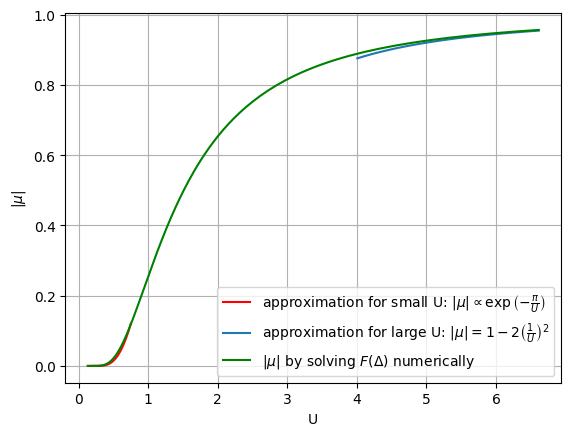

In [51]:
Delta_values = np.logspace(-10, 0.5, 800)

U_values, mu_values = parametric_solution(Delta_values)

small_mask = U_values <= 0.75
approx_small_U = 8 * np.exp(-np.pi / U_values[small_mask])

large_mask = U_values >= 4
approx_large_U = 1 - 2* (1/ U_values[large_mask])**2

plt.plot(U_values[small_mask], approx_small_U, color="red", label=f"approximation for small U: {label_exp}")
plt.plot(U_values[large_mask], approx_large_U, label=f"approximation for large U: {label_large_U}")

plt.plot(U_values, mu_values, label = label_mu, color="green")
plt.legend()
plt.xlabel("U")
plt.ylabel(r"$|\mu|$")
plt.grid(True)
plt.savefig("solving_for_mu")
plt.show()


Task 8f)

In [ ]:
def calculate_D_A_up(omega, Delta):
    omega = np.asarray(omega)
    D = np.zeros_like(omega, dtype=float)

    edge = np.sqrt(Delta**2 + 4)

    # positiver Frequenzbereich: Delta <= omega <= sqrt(Delta^2 + 4)
    mask_pos = (omega >= Delta) & (omega <= edge)

    # negativer Frequenzbereich: -sqrt(Delta^2 + 4) <= omega <= -Delta
    # am Punkt omega = -Delta hat die Formel eine integrable Divergenz,
    # deshalb vermeiden wir exakt den Randpunkt.
    eps = 1e-14
    mask_neg = (omega >= -edge) & (omega <= -Delta - eps)

    D[mask_pos] = (
        1 / (2*np.pi)
        * np.sqrt((omega[mask_pos] - Delta) / (omega[mask_pos] + Delta))
        * np.sqrt(np.maximum(4 + Delta**2 - omega[mask_pos]**2, 0))
    )

    abs_omega = np.abs(omega[mask_neg])

    D[mask_neg] = (
        1 / (2*np.pi)
        * np.sqrt((abs_omega + Delta) / (abs_omega - Delta))
        * np.sqrt(np.maximum(4 + Delta**2 - omega[mask_neg]**2, 0))
    )

    return D

In [ ]:
import pandas as pd

U_targets = np.array([0.5, 1, 4])

rows = []

for U_target in U_targets:
    idx = np.argmin(np.abs(U_values - U_target))

    rows.append({
        "U_target": U_target,
        "U_nearest": U_values[idx],
        "Delta": Delta_values[idx],
        "|mu|": mu_values[idx],
        "error": abs(U_values[idx] - U_target)
    })

df = pd.DataFrame(rows)
print(df)

U =  0.5, Delta = 0.00549603, |mu| = 0.0219841
U =  1.0, Delta = 0.127717, |mu| = 0.255435
U =  4.0, Delta = 1.77659, |mu| = 0.888294


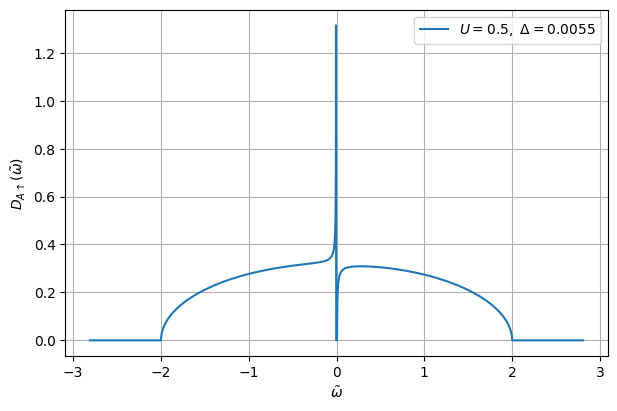

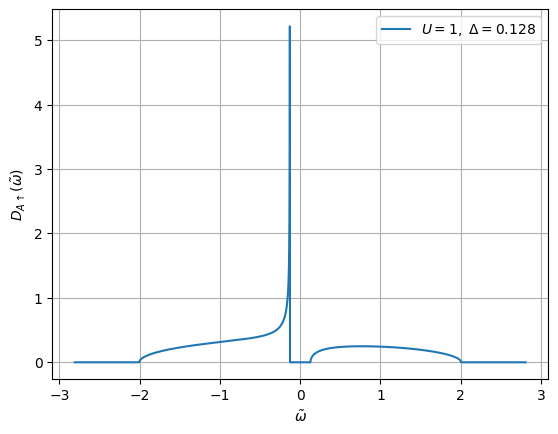

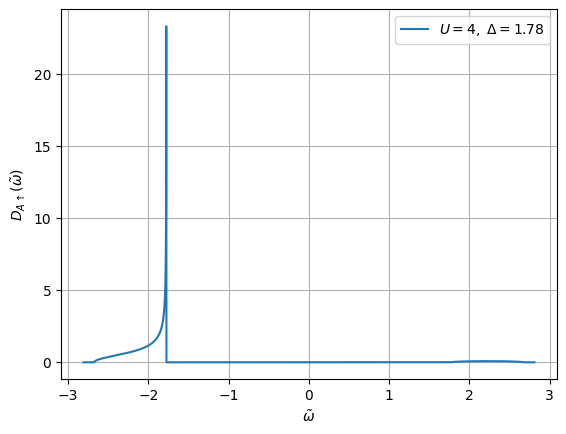

In [ ]:
# Deltas ausrechnen
Delta_values = [calculate_Delta(U) for U in U_values]

for U, Delta in zip(U_values, Delta_values):
    mu = 2 * Delta / U
    print(f"U = {U:4.1f}, Delta = {Delta:.6g}, |mu| = {mu:.6g}")

omega_max = 1.05 * max(np.sqrt(Delta**2 + 4) for Delta in Delta_values)
omega = np.linspace(-omega_max, omega_max, 5000)

plt.figure(figsize=(7, 4.5))

for U, Delta in zip(U_values, Delta_values):
    D = calculate_D_A_up(omega, Delta)

    plt.plot(
        omega,
        D,
        label=fr"$U={U},\ \Delta={Delta:.3g}$"
    )
    plt.xlabel(r"$\tilde{\omega}$")
    plt.ylabel(r"$D_{A\uparrow}(\tilde{\omega})$")
    plt.grid(True)
    plt.legend()
    plt.show()

In [52]:
def calculate_D(omega, Delta):
    D_up_positive_ommega = calculate_D_A_up(omega, Delta)
    D_up_negative_omega = calculate_D_A_up(-omega, Delta)
    D = D_up_positive_ommega + D_up_negative_omega
    return D

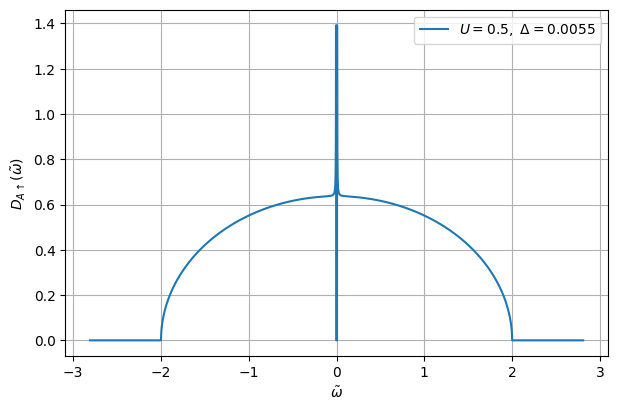

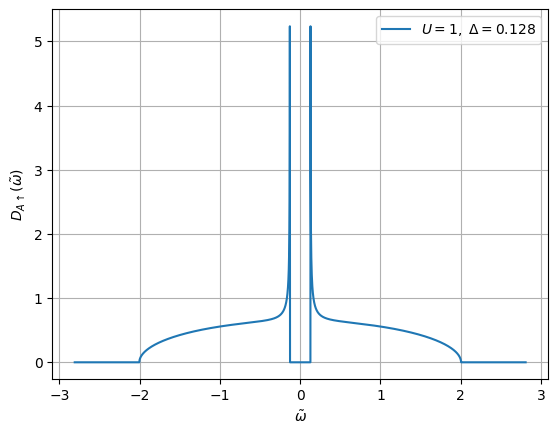

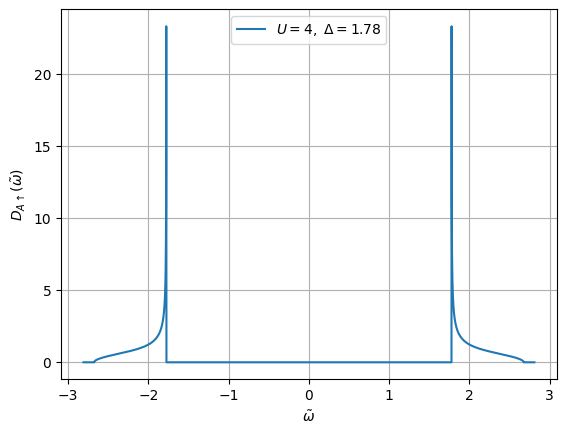

In [58]:
plt.figure(figsize=(7, 4.5))

for U, Delta in zip(U_values, Delta_values):
    D = calculate_D(omega, Delta)

    plt.plot(
        omega,
        D,
        label=fr"$U={U},\ \Delta={Delta:.3g}$"
    )
    plt.xlabel(r"$\tilde{\omega}$")
    plt.ylabel(r"$D_{A\uparrow}(\tilde{\omega})$")
    plt.grid(True)
    plt.legend()
    plt.show()